# STARTER

In [1]:
import sys
import pathlib

# Get project root (parent of generation/)
project_root = pathlib.Path().resolve().parent
sys.path.insert(0, str(project_root))

# MANIFESTO

In [2]:
from scripts.utils.logger import logger

In [3]:
logger_params = {
    "main_folder": "/home/think/Desktop/strats",
    "experiment_name": "RECURSIVE_LSTM_ALLFORONE_PART_A_CONCEPT",
    "date": "2026-03-05",
    "iteration": 1,
    "description": (
        "Como prueba de concepto de la PARTE A"
        "Se entrenara una LSTM con lorenz63 canonico caotico"
        "en modo multivariable 1 (all for one) para las estrategia RECURSIVE,"
        "el proposito es que podamos dejar una precedente para la PARTE B "
    )
}

In [4]:
exp_folder, manifesto_path = logger(logger_params)
print(f"Experiment folder created at: {exp_folder}")
print(f"Manifesto written to: {manifesto_path}")

Experiment folder created at: /home/think/Desktop/strats/RECURSIVE_LSTM_ALLFORONE_PART_A_CONCEPT_2026-03-05_iter1
Manifesto written to: /home/think/Desktop/strats/RECURSIVE_LSTM_ALLFORONE_PART_A_CONCEPT_2026-03-05_iter1/manifesto.txt


# DATA

In [ ]:
from scripts.data_generation.binder import Binder
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scripts.data_generation.tsdg import DynamicalSystem
from sklearn.preprocessing import MinMaxScaler

# --- Data Generation ---
model_name = 'lorenz63'
sigma = 10 
beta = 8/3
rho = 28
params = (sigma, beta, rho)
binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
binder.import_module()      
model_fixed = binder.fixer()
t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 1000)
y0 = np.array([0.1, 0.1, 0.1])
ds1 = DynamicalSystem(model_fixed, y0, t_eval, notebook = True)
_ = ds1.solve()

In [44]:
sample

,x,y,z
1,0.100000,0.100000,0.100000
2,0.218216,0.463733,0.080207
3,0.700173,1.525500,0.099396
4,2.275756,4.943956,0.481638
5,7.205701,15.165543,4.394546
...,...,...,...
996,7.544452,10.906961,20.080116
997,11.201796,14.401905,26.375806
998,12.034234,9.951313,33.751368
999,8.133982,3.658924,31.638599


## Splitting

In [7]:
# --- Convert to dataframe ---
sample = ds1.to_dataframe()

# Train and Test Split
Full = sample.values
n_samples = len(Full)

train_size = int(0.60 * n_samples)   # 60% for training
val_size = int(0.20 * n_samples)     # 20% for validation
test_size = n_samples - train_size - val_size  # remaining 20% for testing

train_data = Full[:train_size]
val_data = Full[train_size:train_size+val_size]
test_data = Full[train_size+val_size:]

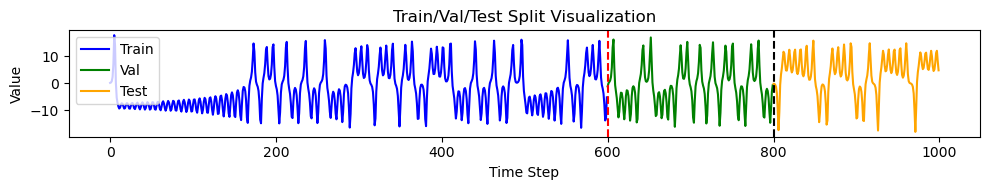

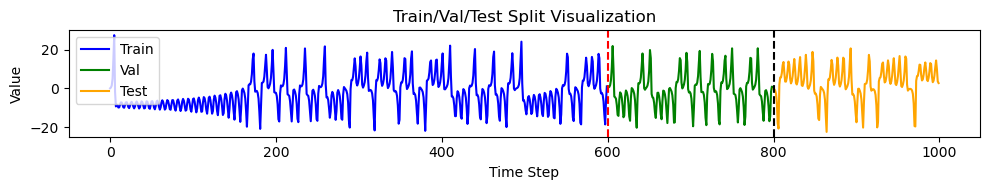

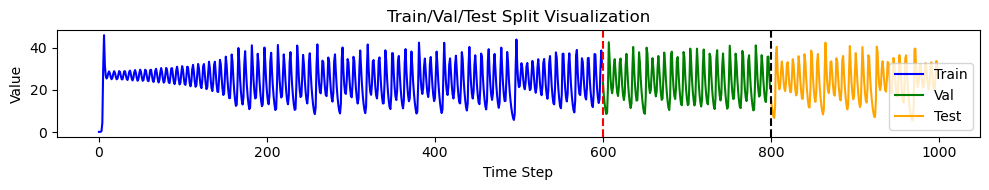

In [8]:
for i in range(len(sample.columns)):
    # Define x-axis ranges based on the lengths
    train_end = len(train_data[:,i])
    val_end = len(train_data[:,i]) + len(val_data[:,i])
    x_train = np.arange(train_end)
    x_val =np.arange(train_end, train_end + len(val_data[:,i]))
    x_test = np.arange(val_end, val_end + len(test_data[:,i]))
    # Plot
    plt.figure(figsize=(10, 2))
    plt.plot(x_train, train_data[:,i], label='Train', color='blue')
    plt.plot(x_val, val_data[:,i], label='Val', color='green')
    plt.plot(x_test, test_data[:,i], label='Test', color='orange')

    # Optional vertical line to indicate the split
    plt.axvline(x=train_end, color='red', linestyle='--') #label='Train/Test Split'
    plt.axvline(x=val_end, color='black', linestyle='--') #label='Train/Test Split'
    plt.legend()
    plt.title("Train/Val/Test Split Visualization")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

In [9]:
train_data

array([[  0.1       ,   0.1       ,   0.1       ],
       [  0.21821629,   0.46373299,   0.08020736],
       [  0.70017301,   1.52550036,   0.09939649],
       ...,
       [-13.87488445, -18.46459772,  28.86586622],
       [-12.89551191,  -6.26438654,  38.73761873],
       [ -5.28321045,   1.09895396,  31.06253991]])

In [10]:
train_data.shape

(600, 3)

## Scaling

In [11]:
# --- Scaling ---
scaler = MinMaxScaler()

# .reshape(-1, 1)) then .flatten() if we want to pursue univariate
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

# # We fit on train but immediately transform test here for simplicity
# test_scaled  = scaler.transform(test_data.reshape(-1, 1)).flatten()
# # If you want the prediction back in original units:
# # yhat = scaler.inverse_transform(yhat_scaled)

In [12]:
train_scaled.shape

(600, 3)

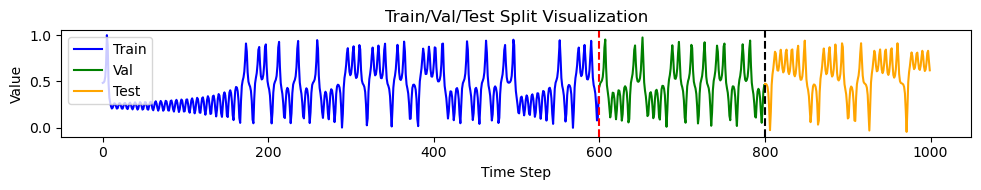

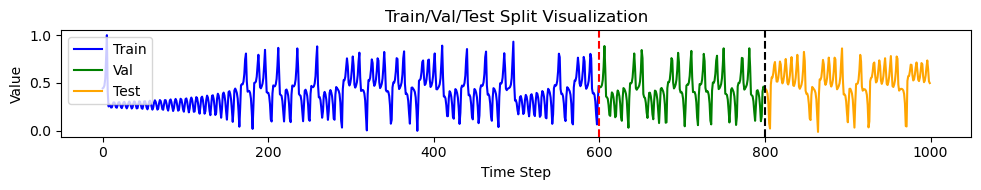

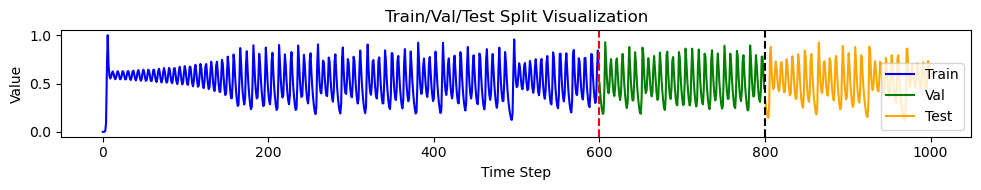

In [13]:
for i in range(len(sample.columns)):
    # Define x-axis ranges based on the lengths
    train_end = len(train_scaled[:,i])
    val_end = len(train_scaled[:,i]) + len(val_scaled[:,i])
    x_train = np.arange(train_end)
    x_val =np.arange(train_end, train_end + len(val_scaled[:,i]))
    x_test = np.arange(val_end, val_end + len(test_scaled[:,i]))
    # Plot
    plt.figure(figsize=(10, 2))
    plt.plot(x_train, train_scaled[:,i], label='Train', color='blue')
    plt.plot(x_val, val_scaled[:,i], label='Val', color='green')
    plt.plot(x_test, test_scaled[:,i], label='Test', color='orange')

    # Optional vertical line to indicate the split
    plt.axvline(x=train_end, color='red', linestyle='--') #label='Train/Test Split'
    plt.axvline(x=val_end, color='black', linestyle='--') #label='Train/Test Split'
    plt.legend()
    plt.title("Train/Val/Test Split Visualization")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

## Temporal windowing

In [14]:
from numpy import array

In [15]:
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix, :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [16]:
train_scaled

array([[4.84937225e-01, 4.44672532e-01, 4.30745881e-04],
       [4.88369548e-01, 4.52070525e-01, 0.00000000e+00],
       [5.02362806e-01, 4.73665895e-01, 4.17611642e-04],
       ...,
       [7.91867683e-02, 6.70857213e-02, 6.26460412e-01],
       [1.07622127e-01, 3.15226774e-01, 8.41298717e-01],
       [3.28639683e-01, 4.64990334e-01, 6.74266478e-01]])

In [17]:
# choose a number of time steps
n_steps_in, n_steps_out = 1, 1
# convert into input/output
X, y = split_sequences(train_scaled, n_steps_in, n_steps_out)

In [18]:
X.shape

(599, 1, 3)

In [19]:
for i in range(len(X)):
    print(X[i], y[i])

[[4.84937225e-01 4.44672532e-01 4.30745881e-04]] [[0.48836955 0.45207053 0.        ]]
[[0.48836955 0.45207053 0.        ]] [[5.02362806e-01 4.73665895e-01 4.17611642e-04]]
[[5.02362806e-01 4.73665895e-01 4.17611642e-04]] [[0.54810869 0.54319413 0.0087363 ]]
[[0.54810869 0.54319413 0.0087363 ]] [[0.69124601 0.7510918  0.09389267]]
[[0.69124601 0.7510918  0.09389267]] [[1.         1.         0.65089077]]
[[1.         1.         0.65089077]] [[0.88991403 0.40682383 1.        ]]
[[0.88991403 0.40682383 1.        ]] [[0.48298014 0.2550093  0.68967235]]
[[0.48298014 0.2550093  0.68967235]] [[0.32440079 0.27378986 0.5822419 ]]
[[0.32440079 0.27378986 0.5822419 ]] [[0.26795992 0.2633323  0.55180352]]
[[0.26795992 0.2633323  0.55180352]] [[0.23049577 0.24360234 0.56664925]]
[[0.23049577 0.24360234 0.56664925]] [[0.20839492 0.24544559 0.60586776]]
[[0.20839492 0.24544559 0.60586776]] [[0.21722097 0.2734426  0.62521321]]
[[0.21722097 0.2734426  0.62521321]] [[0.24601544 0.29731473 0.60394612]]
[[

### validation data

In [45]:
# --- Generate Validation Sequences ---
# We use the same n_steps_in and n_steps_out as the training data
X_val, y_val = split_sequences(val_scaled, n_steps_in, n_steps_out)

# LSTM MODEL

In [21]:
# the dataset knows the number of featrues, e.g. 2
n_features = X.shape[2]

# multivariate multi-step  encoder-decoder lstm example

from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Reshape

def vanilla_lstm(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out * n_features))  # predict all future timesteps × features
    model.add(Reshape((n_steps_out, n_features)))  # reshape to proper output structure
    model.compile(optimizer='adam', loss='mse')
    return model

## Model Training

In [46]:
model_recursive = vanilla_lstm(n_steps_in, n_steps_out, n_features)
# model_recursive.fit(X, y, epochs=800, verbose=0)
# --- Training with Validation and History ---
# We capture the output in 'history' and add the validation_data argument
print("Training model... this might take a minute.")
history = model_recursive.fit(
    X, y, 
    epochs=800, 
    validation_data=(X_val, y_val), 
    verbose=0
)

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training model... this might take a minute.


## Model saving

In [47]:
import os

# Put this right after: model_recursive.fit(X, y, epochs=800, verbose=0)
model_filename = f"lstm_rho_{rho}.h5" # Name it based on the chaos level!
model_path = os.path.join(exp_folder, model_filename)

model_recursive.save(model_path)
print(f"Dude, model securely saved to: {model_path}")

Dude, model securely saved to: /home/think/Desktop/strats/RECURSIVE_LSTM_ALLFORONE_PART_A_CONCEPT_2026-03-05_iter1/lstm_rho_28.h5


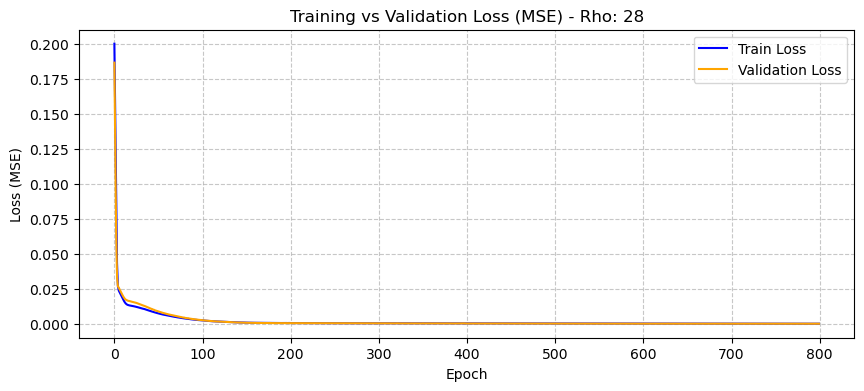

In [48]:
# --- Visualize the Loss ---
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title(f'Training vs Validation Loss (MSE) - Rho: {rho}')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Model Forecast

In [ ]:
# from sklearn import metrics
# from scipy.stats import skew
# import numpy as np


# def recursive_predictions(starter_sample, horizon, model, scaler = None):
#     # Initialize input, start with the last value of the training data
#     n_steps_in = starter_sample.shape[0]
#     n_features = starter_sample.shape[1]
#     uno = starter_sample.reshape((1, n_steps_in, n_features))
#     # List to store predictions
#     predictions = []
#     # Loop to predict one step at a time
#     for i in range(horizon):
#         yhat_scaled = model.predict(uno, verbose=0)
#         # Save prediction in original units
#         if scaler is not None:
#             yhat_inv = scaler.inverse_transform(yhat_scaled)
#             predictions.append(yhat_inv)
#         else:
#             predictions.append(yhat_scaled)

#         # Feed back the scaled value to the model
#         uno = yhat_scaled.reshape((1, n_steps_in, n_features)) 
     
#     # Convert predictions to numpy array
#     predictions = np.array(predictions)
#     return predictions

In [49]:
def recursive_predictions(starter_sample, horizon, model, scaler=None):
    # starter_sample is passed as shape (1, 3)
    n_steps_in = starter_sample.shape[0] 
    n_features = starter_sample.shape[1]
    
    # Keras needs 3D input: (batch, timesteps, features) -> (1, 1, 3)
    uno = starter_sample.reshape((1, n_steps_in, n_features))
    predictions = []
    
    for i in range(horizon):
        # yhat_scaled comes out as (1, 1, 3) because of your Reshape layer
        yhat_scaled = model.predict(uno, verbose=0)
        
        # Squeeze it down to 2D (1, 3) so the scaler doesn't crash
        yhat_2d = yhat_scaled.reshape((1, n_features))
        
        if scaler is not None:
            yhat_inv = scaler.inverse_transform(yhat_2d)
            # Append just the flat 1D array [x, y, z] to keep the list clean
            predictions.append(yhat_inv[0]) 
        else:
            predictions.append(yhat_2d[0])

        # Feed the 3D tensor back into the loop for the next step
        uno = yhat_scaled 
     
    # Convert predictions to a clean (horizon, n_features) numpy array
    return np.array(predictions)

In [50]:
val_scaled[-1]

array([0.45925362, 0.4489519 , 0.45194522])

In [51]:
starter_sample = val_scaled[-1].reshape((1, n_features))
horizon = 200
recurs_preds_1 = recursive_predictions(starter_sample, horizon, model_recursive, scaler = None)

In [52]:
recurs_preds_1

array([[ 0.4729284 ,  0.43368804,  0.34245896],
       [ 0.4630565 ,  0.40495455,  0.25133952],
       [ 0.41895717,  0.35241842,  0.18638946],
       [ 0.32227945,  0.25364292,  0.19941784],
       [ 0.1396822 ,  0.05517464,  0.3690332 ],
       [-0.01272285,  0.07977875,  0.8416517 ],
       [ 0.21513341,  0.5264821 ,  0.83398926],
       [ 0.4607169 ,  0.52530295,  0.62244046],
       [ 0.5411478 ,  0.5296777 ,  0.47527304],
       [ 0.60630226,  0.59175724,  0.39425427],
       [ 0.7104055 ,  0.69491005,  0.40896887],
       [ 0.8354569 ,  0.7573403 ,  0.59336174],
       [ 0.81243384,  0.5922559 ,  0.70568967],
       [ 0.6689969 ,  0.49283946,  0.60403466],
       [ 0.5923824 ,  0.51043475,  0.47135755],
       [ 0.6136326 ,  0.5831637 ,  0.3952913 ],
       [ 0.7059359 ,  0.6871244 ,  0.4036579 ],
       [ 0.8293206 ,  0.7565566 ,  0.57900035],
       [ 0.81848526,  0.60387796,  0.7046493 ],
       [ 0.6774968 ,  0.4956662 ,  0.6133754 ],
       [ 0.5950269 ,  0.50877744,  0.477

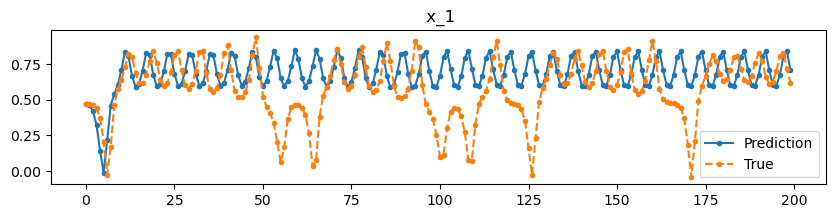

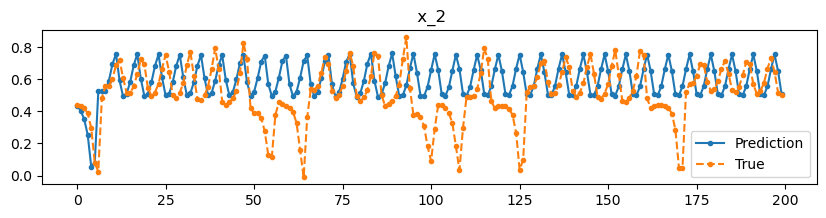

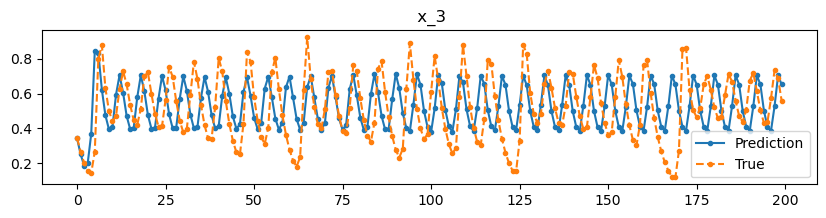

In [53]:
import matplotlib.pyplot as plt

n_features = 3

for i in range(n_features):
    plt.figure(figsize=(10, 2))
    plt.plot(recurs_preds_1[:, i], linestyle='-', marker='.', label='Prediction')
    plt.plot(test_scaled[:200, i], linestyle='--', marker='.', label='True')
    plt.title(f' x_{i+1}')
    plt.legend()
    #plt.xlim(0,20)
    plt.show()